In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns

url = "https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/imdb.csv"
df = pd.read_csv(url)

df.head()


,Unnamed: 0,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,...,Drama,Music,Biography,Romance,History,Crime,Western,War,Musical,Sport
0,0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,...,False,False,False,False,False,False,False,False,False,False
1,1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,...,False,False,False,False,False,False,False,False,False,False
2,2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,...,False,False,False,False,False,False,False,False,False,False
3,3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,...,False,False,False,False,False,False,False,False,False,False
4,4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,...,False,False,False,False,False,False,False,False,False,False


[Text(0.5, 1.0, 'Average IMDB Rating by Year')]

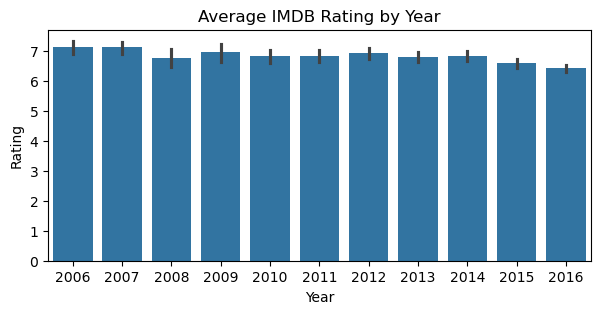

In [19]:
plt.figure(figsize=(7,3))
bar = sns.barplot(data = df, x = "Year", y = "Rating")
bar.set(title = "Average IMDB Rating by Year")

In [20]:
# need to get a list of ratings for each year to get an average 
# making a generative list by looping over years

years = sorted(df["Year"].unique())  # need unique years and set it so that it is in order
ratings_yr = [df.loc[df["Year"] == year, "Rating"] for year in years]  # one line loop

# ANOVA test , start with f and p

f, p = stats.f_oneway(*ratings_yr)  # need to unpack the list of ratings by year with *
dfb = len(years) - 1
dfw = len(df) - len(years)
alpha = 0.05
critical = stats.f.ppf(1 - alpha, dfb, dfw)

print(f"f={f:.4f}, p={p:.4f}, critical={critical:.4f}")


f=6.0455, p=0.0000, critical=1.8403


In [21]:
# tukey's HSD test

tukey = stats.tukey_hsd(*ratings_yr)
print(tukey)
print(years)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.009     1.000    -0.616     0.598
 (0 - 2)      0.340     0.779    -0.269     0.950
 (0 - 3)      0.164     0.999    -0.448     0.777
 (0 - 4)      0.298     0.870    -0.292     0.889
 (0 - 5)      0.287     0.889    -0.298     0.872
 (0 - 6)      0.200     0.991    -0.383     0.783
 (0 - 7)      0.313     0.751    -0.234     0.859
 (0 - 8)      0.287     0.827    -0.253     0.827
 (0 - 9)      0.523     0.048     0.002     1.043
 (0 - 10)      0.688     0.000     0.208     1.169
 (1 - 0)      0.009     1.000    -0.598     0.616
 (1 - 2)      0.349     0.690    -0.232     0.930
 (1 - 3)      0.173     0.997    -0.411     0.757
 (1 - 4)      0.307     0.799    -0.254     0.868
 (1 - 5)      0.296     0.825    -0.259     0.851
 (1 - 6)      0.209     0.980    -0.344     0.762
 (1 - 7)      0.322     0.635    -0.192     0.836
 (1 - 8)      0.296     0.728    -0.211    

In [22]:
# pairwise tukey hsd

tukey = pairwise_tukeyhsd(
    endog=df["Rating"],
    groups=df["Year"],
    alpha=0.05,
)
tukey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
2006,2007,0.009,1.0,-0.598,0.6159,False
2006,2008,-0.3404,0.7793,-0.95,0.2692,False
2006,2009,-0.1642,0.9987,-0.7765,0.4481,False
2006,2010,-0.2983,0.8695,-0.889,0.2923,False
2006,2011,-0.2869,0.8894,-0.8716,0.2978,False
2006,2012,-0.2,0.9905,-0.7828,0.3828,False
2006,2013,-0.3129,0.7512,-0.8594,0.2335,False
2006,2014,-0.2872,0.8273,-0.8273,0.2528,False
2006,2015,-0.5226,0.0481,-1.0432,-0.002,True
2006,2016,-0.6883,0.0002,-1.169,-0.2076,True


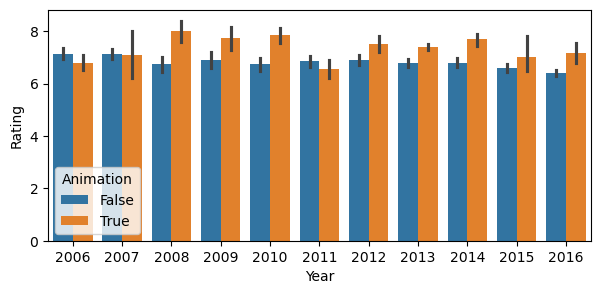

In [23]:
plt.figure(figsize=(7,3))
bar = sns.barplot(data = df, x = "Year", y = "Rating", hue = "Animation")

In [26]:
animated = df.loc[df["Animation"] == True, "Rating"]
non_animated = df.loc[df["Animation"] == False, "Rating"]

t, p = stats.ttest_ind(animated, non_animated)
deg_f = len(animated) + len(non_animated) - 2
alpha = 0.05
critical = stats.t.ppf(1 - alpha/2, deg_f)
print(f"t={t:.4f}, p={p:.4f}, critical={critical:.4f}")

t=4.6113, p=0.0000, critical=1.9623


Text(0.5, 0.2, 't=4.6113\np=0.0000\ncritical=1.9623')

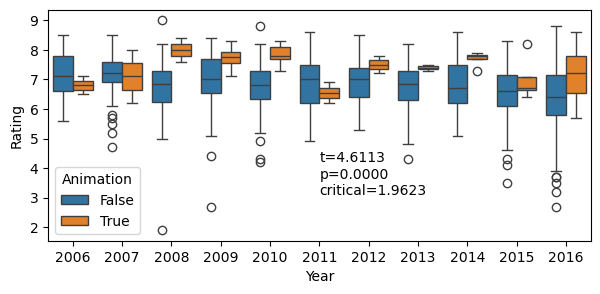

In [27]:
plt.figure(figsize=(7,3))
box = sns.boxplot(data = df, x = "Year", y = "Rating", hue = "Animation")
box.text(x=0.5, y = 0.2, s= f"t={t:.4f}\np={p:.4f}\ncritical={critical:.4f}", transform=box.transAxes)

In [28]:
groups = [
    ["Action", "Adventure", "Sci-Fi" ],
    ["Drama"],
    ["Comedy", "Romance"],
    ["Animation", "Adventure", "Comedy"]
]

df["Genre"] = df["Genre"].apply(lambda x: x.split(","))
df["Genre"]

0       [Action, Adventure, Sci-Fi]
1      [Adventure, Mystery, Sci-Fi]
2                [Horror, Thriller]
3       [Animation, Comedy, Family]
4      [Action, Adventure, Fantasy]
                   ...             
995         [Crime, Drama, Mystery]
996                        [Horror]
997         [Drama, Music, Romance]
998             [Adventure, Comedy]
999       [Comedy, Family, Fantasy]
Name: Genre, Length: 1000, dtype: object

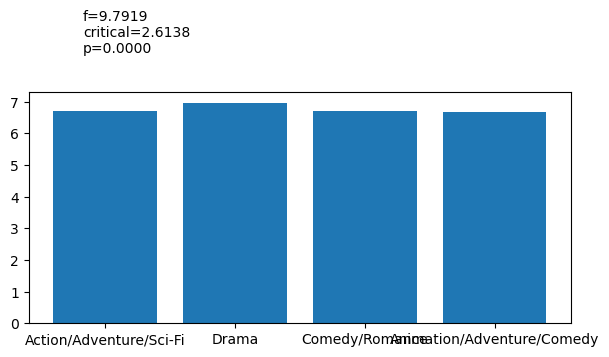

In [29]:
group_samples = [df.loc[df["Genre"].apply(lambda x: bool(set(x) & set(g))), "Rating"] for g in groups]
f, p = stats.f_oneway(*group_samples)
dfb = len(group_samples) - 1
dfw = len(df) - len(group_samples)
critical = stats.f.ppf(1 - alpha, dfb, dfw)

text = f"""f={f:.4f}
critical={critical:.4f}
p={p:.4f}
"""

plt.figure(figsize=(7,3))
cols = ["/".join(g) for g in groups]
heights = [s.mean() for s in group_samples]
plt.bar(x=cols, height=heights)
plt.text(x=0.1, y=1.1, s=text, transform=plt.gca().transAxes)
plt.show()

In [31]:
# tukey's HSD test

tukey = stats.tukey_hsd(*group_samples)
print(tukey)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.241     0.000    -0.390    -0.093
 (0 - 2)      0.009     0.999    -0.155     0.173
 (0 - 3)      0.022     0.983    -0.129     0.172
 (1 - 0)      0.241     0.000     0.093     0.390
 (1 - 2)      0.250     0.000     0.091     0.409
 (1 - 3)      0.263     0.000     0.118     0.408
 (2 - 0)     -0.009     0.999    -0.173     0.155
 (2 - 1)     -0.250     0.000    -0.409    -0.091
 (2 - 3)      0.013     0.997    -0.148     0.174
 (3 - 0)     -0.022     0.983    -0.172     0.129
 (3 - 1)     -0.263     0.000    -0.408    -0.118
 (3 - 2)     -0.013     0.997    -0.174     0.148

